In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from utils.collection.tensors import import_npz
from utils.preprocessing.splitting import split_and_balance, task2_preprocess
from utils.exploration.processed_data import print_single_file_info, get_agglomerated_labels, plot_class_distribution
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

cur_dir = Path(os.getcwd())
proj_dir = cur_dir.resolve().parent.parent
LABEL_DATA_PATH = proj_dir / "data" / "labels"
FEATURE_DATA_PATH = proj_dir / "data" / "features"
TASK_1_DATA_PATH = proj_dir / "data" / "split" / "task_1"
TASK_2_DATA_PATH = proj_dir / "data" / "split" / "task_2"

PATH_SAVE_PLOTS = proj_dir / 'doc' / 'src' / 'splitting'
SAVE = True

SELECTED_SUBJECTS = [4,12,13,19]
SELECTED_NAMES = [f"chb{str(pid).zfill(2)}" for pid in SELECTED_SUBJECTS]
SELECTED_NAMES

['chb04', 'chb12', 'chb13', 'chb19']

# Data Splitting

The system processes data extracted from the `features` and `labels` files to generate the datasets required for model training. For each processed file, the procedure follows these steps:

1.  **Chronological Splitting:** The dataset is divided in strict chronological order to respect the sequential nature of the EEG signal. This ensures the integrity of the **train**, **validation**, and **test** sets, preventing "look-ahead bias."
2.  **Class Balancing:** The training and validation sets are processed using a **random undersampling** technique. This step is essential to address the severe class imbalance between rare pre-ictal events and long periods of normal activity (inter-ictal).
3.  **Task 2 Filtering (Pre-ictal Prediction):** For the pre-seizure analysis, samples labeled as active seizures (ictal) are removed from the dataset. The target labels are then reassigned to focus on predicting the specific time window between **1 and 10 minutes** before the seizure onset.
4.  **Data Archiving:** The final results are saved in compressed `.npz` files to optimize disk space and loading speed. Each file contains the following keys:
    * **Train Set:** `X_train`, `y_train`, `t_train`
    * **Validation Set:** `X_val`, `y_val`, `t_val`
    * **Test Set:** `X_test`, `y_test`, `t_test` (maintained as imbalanced and chronological to allow for a realistic performance evaluation)
    * **Metadata:** `feature_names`, `channels`

In [2]:
for p_name in tqdm(SELECTED_NAMES, desc="Subjects"):    
    
    print(f"\nElaborating {p_name}")
    # define paths
    X_data_dir = FEATURE_DATA_PATH / p_name
    y_data_dir = LABEL_DATA_PATH / p_name
    task_1_dir = TASK_1_DATA_PATH / p_name
    task_2_dir = TASK_2_DATA_PATH / p_name
    task_1_dir.mkdir(parents=True, exist_ok=True)
    task_2_dir.mkdir(parents=True, exist_ok=True)
    
    # find files
    X_data_files = sorted(list(X_data_dir.glob("*.npz")))
    y_data_files = sorted(list(y_data_dir.glob("*.npz")))
    
    for x_path, y_path in tqdm(zip(X_data_files, y_data_files), total=len(X_data_files), desc=f"Labels ({p_name})", leave=False):
        
        # load file
        X_data = np.load(x_path)
        X = X_data["features"]
        feature_names = X_data["feature_names"]
        times = X_data['times']
        channels = X_data['channels']
        
        del X_data
        
        y_data = np.load(y_path)
        y_task_1 = y_data["y_task1"]
        y_task_2 = y_data["y_task2"]
        
        del y_data

        print("\n|--- Splitting task 1 ---|")
        train_1, val_1, test_1 = split_and_balance(X, y_task_1, times)
        
        # save Task 01 datasets
        np.savez(task_1_dir / x_path.name, 
                X_train=train_1[0], y_train=train_1[1], t_train=train_1[2],
                X_val=val_1[0], y_val=val_1[1], t_val=val_1[2],
                X_test=test_1[0], y_test=test_1[1], t_test=test_1[2],
                feature_names=feature_names,
                channels=channels
                )
        
        print("\n|-----------------------|")

        del train_1, val_1, test_1
        
        print("\n|--- Splitting task 2 ---|")

        X_task_2, y_task_2, times_2 = task2_preprocess(X, y_task_2, times)
        
        del X, y_task_1, times

        train_2, val_2, test_2= split_and_balance(X_task_2, y_task_2, times_2)
        
        del X_task_2, y_task_2, times_2
        
        # save Task 02 datasets
        np.savez(task_2_dir / x_path.name, 
                X_train=train_2[0], y_train=train_2[1], t_train=train_2[2],
                X_val=val_2[0], y_val=val_2[1], t_val=val_2[2],
                X_test=test_2[0], y_test=test_2[1], t_test=test_2[2],
                feature_names=feature_names,
                channels=channels
                )
        
        print("\n|-----------------------|")

        del train_2, val_2, test_2, feature_names, channels
        gc.collect()
        
    print(f"\nFinish elaborating {p_name}")

print("\nSplitting completed.")

Subjects:   0%|          | 0/4 [00:00<?, ?it/s]


Elaborating chb04


Labels (chb04):   0%|          | 0/5 [00:00<?, ?it/s]


|--- Splitting task 1 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 4030       | 4030       | 0         
Val        | 863        | 863        | 0         
Test       | 865        | 865        | 0         

|-----------------------|

|--- Splitting task 2 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 4030       | 4030       | 0         
Val        | 863        | 863        | 0         
Test       | 865        | 865        | 0         

|-----------------------|

|--- Splitting task 1 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 4030       | 4030       | 0         
Val        | 863        | 863        | 0         
Test       | 865        | 865        | 0         

|-----------------------|

|--- Splitting task 2 ---|
Set        | Size       | Class 0    | Class 1   
----

Labels (chb12):   0%|          | 0/10 [00:00<?, ?it/s]


|--- Splitting task 1 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 52         | 26         | 26        
Val        | 216        | 216        | 0         
Test       | 217        | 203        | 14        

|-----------------------|

|--- Splitting task 2 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 434        | 217        | 217       
Val        | 180        | 90         | 90        
Test       | 211        | 84         | 127       

|-----------------------|

|--- Splitting task 1 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 56         | 28         | 28        
Val        | 24         | 12         | 12        
Test       | 217        | 217        | 0         

|-----------------------|

|--- Splitting task 2 ---|
Set        | Size       | Class 0    | Class 1   
----

Labels (chb13):   0%|          | 0/8 [00:00<?, ?it/s]


|--- Splitting task 1 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 40         | 20         | 20        
Val        | 215        | 215        | 0         
Test       | 217        | 217        | 0         

|-----------------------|

|--- Splitting task 2 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 432        | 216        | 216       
Val        | 212        | 212        | 0         
Test       | 214        | 214        | 0         

|-----------------------|

|--- Splitting task 1 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 60         | 30         | 30        
Val        | 215        | 215        | 0         
Test       | 217        | 217        | 0         

|-----------------------|

|--- Splitting task 2 ---|
Set        | Size       | Class 0    | Class 1   
----

Labels (chb19):   0%|          | 0/3 [00:00<?, ?it/s]


|--- Splitting task 1 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 66         | 33         | 33        
Val        | 216        | 216        | 0         
Test       | 217        | 217        | 0         

|-----------------------|

|--- Splitting task 2 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 192        | 96         | 96        
Val        | 211        | 211        | 0         
Test       | 213        | 213        | 0         

|-----------------------|

|--- Splitting task 1 ---|
Set        | Size       | Class 0    | Class 1   
--------------------------------------------------
Train      | 1006       | 1006       | 0         
Val        | 66         | 33         | 33        
Test       | 217        | 217        | 0         

|-----------------------|

|--- Splitting task 2 ---|
Set        | Size       | Class 0    | Class 1   
----

## Data Consistency & Distribution Check
We will compare the global distribution (Pre-splitting) against the individual Train, Val, and Test subsets (Post-splitting) for both Task 1 and Task 2.

In [3]:
p_name = "chb12"
label_path = LABEL_DATA_PATH / p_name
files = sorted(list(label_path.glob("*.npz")))

t1_path = TASK_1_DATA_PATH / p_name
t2_path = TASK_2_DATA_PATH / p_name

t1_files = sorted(list(t1_path.glob("*.npz")))
t2_files = sorted(list(t2_path.glob("*.npz")))

### Pre-splitting

Available keys for the file are: ['y_task1', 'y_task2', 'times']
Shape of y_task1: (1441,)
Shape of y_task2: (1441,)



--- Pre-splitting Class Distribution ---
Class 0.0: 13691 samples (98.31%)
Class 1.0: 235 samples (1.69%)


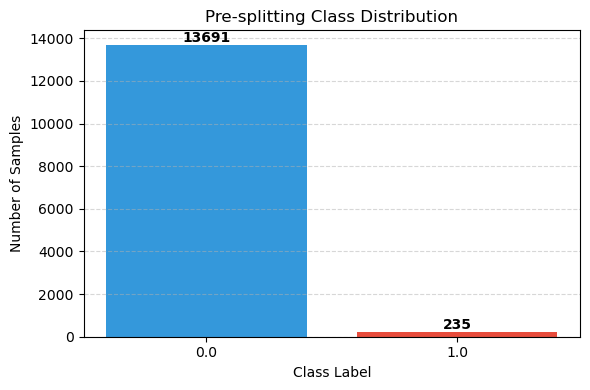

In [4]:
print_single_file_info(files[0], keys=['y_task1', 'y_task2'])
y1 = get_agglomerated_labels(files, label_key='y_task1')
plot_class_distribution(labels=y1, title='Pre-splitting Class Distribution', save=SAVE, save_path=PATH_SAVE_PLOTS, name='pre_splitting_class_distr.png')

### for task1

ANALYSIS OF THE chb12 SUBJECTS DATA
-------------------- TASK1 --------------------
--- Train Set ---
Class 0.0: 2225 samples (91.41%)
Class 1.0: 209 samples (8.59%)


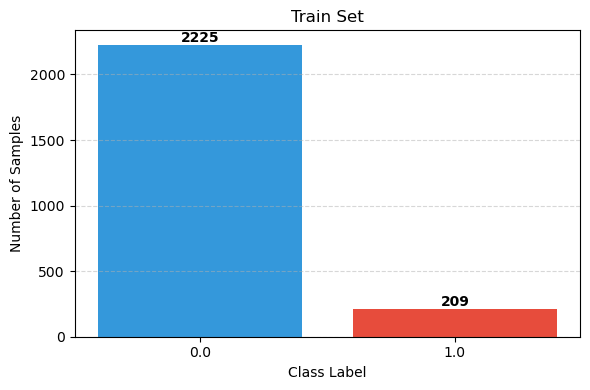


Available keys for the file are: ['X_train', 'y_train', 't_train', 'X_val', 'y_val', 't_val', 'X_test', 'y_test', 't_test', 'feature_names', 'channels']
The shape of the set is: (52, 793)
The shape of the target label is: (52,)
The features that we have are (793,)



--- Validation Set ---
Class 0.0: 1880 samples (99.37%)
Class 1.0: 12 samples (0.63%)


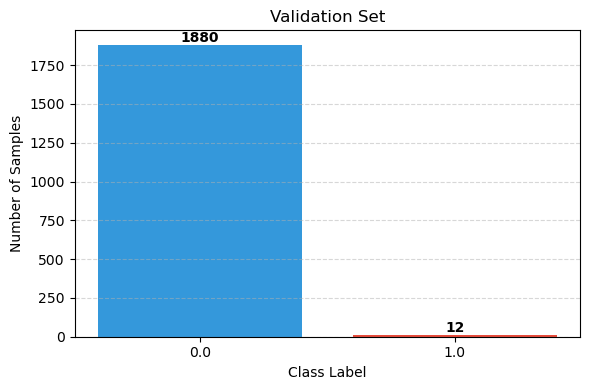


Available keys for the file are: ['X_train', 'y_train', 't_train', 'X_val', 'y_val', 't_val', 'X_test', 'y_test', 't_test', 'feature_names', 'channels']
The shape of the set is: (216, 793)
The shape of the target label is: (216,)
The features that we have are (793,)



--- Test Set ---
Class 0.0: 2086 samples (99.33%)
Class 1.0: 14 samples (0.67%)


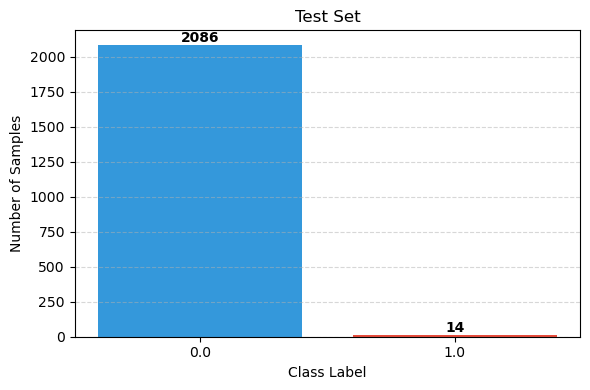


Available keys for the file are: ['X_train', 'y_train', 't_train', 'X_val', 'y_val', 't_val', 'X_test', 'y_test', 't_test', 'feature_names', 'channels']
The shape of the set is: (217, 793)
The shape of the target label is: (217,)
The features that we have are (793,)





In [5]:
print(f'ANALYSIS OF THE {p_name} SUBJECTS DATA')
print('-'*20, 'TASK1', '-'*20)

# 1. Process Train
y_train = get_agglomerated_labels(t1_files, label_key='y_train')
plot_class_distribution(y_train, title=f"Train Set", save=SAVE, save_path=PATH_SAVE_PLOTS, name='task1_train_class_distr.png')
print()
print_single_file_info(t1_files[0], keys=['X_train', 'y_train'])

# 2. Process Val
y_val = get_agglomerated_labels(t1_files, label_key='y_val')
plot_class_distribution(y_val, title=f"Validation Set", save=SAVE, save_path=PATH_SAVE_PLOTS, name='task1_val_class_distr.png')
print()
print_single_file_info(t1_files[0], keys=['X_val', 'y_val'])

# 3. Process Test
y_test = get_agglomerated_labels(t1_files, label_key='y_test')
plot_class_distribution(y_test, title=f"Test Set", save=SAVE, save_path=PATH_SAVE_PLOTS, name='task1_test_class_distr.png')
print()
print_single_file_info(t1_files[0], keys=['X_test', 'y_test'])

### for task 2

ANALYSIS OF THE chb12 SUBJECTS DATA
-------------------- TASK2 --------------------
--- Train Set ---
Class 0.0: 4132 samples (66.13%)
Class 1.0: 2116 samples (33.87%)


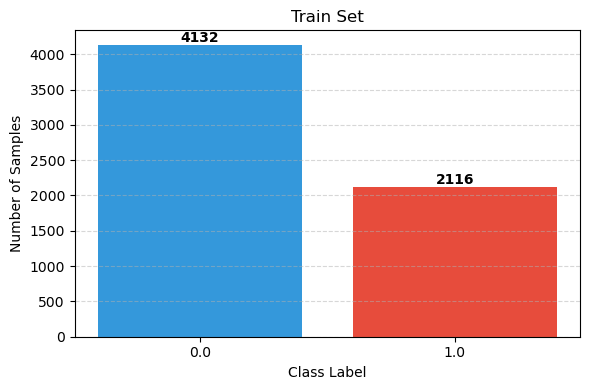


Available keys for the file are: ['X_train', 'y_train', 't_train', 'X_val', 'y_val', 't_val', 'X_test', 'y_test', 't_test', 'feature_names', 'channels']
The shape of the set is: (434, 793)
The shape of the target label is: (434,)
The features that we have are (793,)



--- Validation Set ---
Class 0.0: 1810 samples (90.95%)
Class 1.0: 180 samples (9.05%)


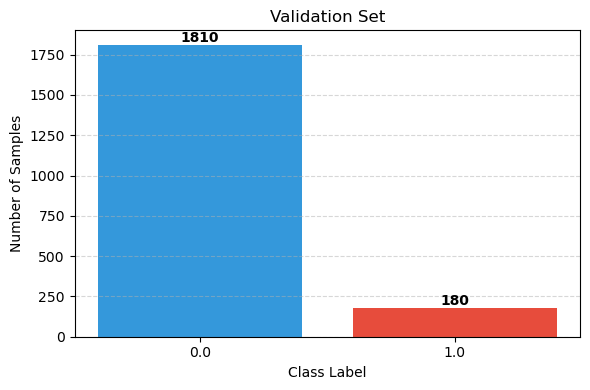


Available keys for the file are: ['X_train', 'y_train', 't_train', 'X_val', 'y_val', 't_val', 'X_test', 'y_test', 't_test', 'feature_names', 'channels']
The shape of the set is: (180, 793)
The shape of the target label is: (180,)
The features that we have are (793,)



--- Test Set ---
Class 0.0: 1936 samples (93.84%)
Class 1.0: 127 samples (6.16%)


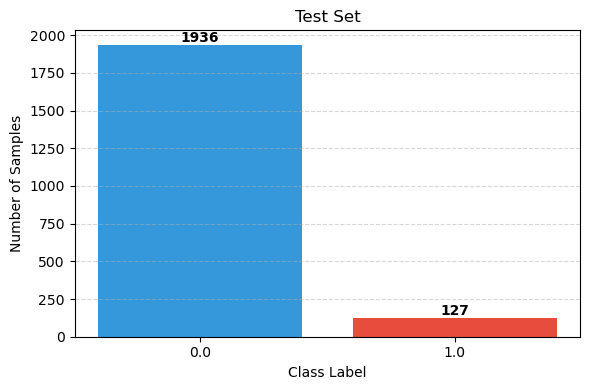


Available keys for the file are: ['X_train', 'y_train', 't_train', 'X_val', 'y_val', 't_val', 'X_test', 'y_test', 't_test', 'feature_names', 'channels']
The shape of the set is: (211, 793)
The shape of the target label is: (211,)
The features that we have are (793,)





In [6]:
print(f'ANALYSIS OF THE {p_name} SUBJECTS DATA')
print('-'*20, 'TASK2', '-'*20)

# 1. Process Train
y_train = get_agglomerated_labels(t2_files, label_key='y_train')
plot_class_distribution(y_train, title=f"Train Set", save=SAVE, save_path=PATH_SAVE_PLOTS, name='task2_train_class_distr.png')
print()
print_single_file_info(t2_files[0], keys=['X_train', 'y_train'])

# 2. Process Val
y_val = get_agglomerated_labels(t2_files, label_key='y_val')
plot_class_distribution(y_val, title=f"Validation Set", save=SAVE, save_path=PATH_SAVE_PLOTS, name='task2_val_class_distr.png')
print()
print_single_file_info(t2_files[0], keys=['X_val', 'y_val'])

# 3. Process Test
y_test = get_agglomerated_labels(t2_files, label_key='y_test')
plot_class_distribution(y_test, title=f"Test Set", save=SAVE, save_path=PATH_SAVE_PLOTS, name='task2_test_class_distr.png')
print()
print_single_file_info(t2_files[0], keys=['X_test', 'y_test'])

### Insights

The diagnostic plots confirm that the class distribution remains imbalanced across all splits. 

This is a direct result of our processing pipeline, which performs splitting on a per-file basis and for segments with no seizures the code maintains and splits all the data, no matter the label. Because many segments contain no target events, a strict balancing approach (undersampling the majority class) would lead to a significant loss of data, potentially starving the model of the temporal context needed for robust feature extraction.

> We decided to maintain the current imbalanced distribution to ensure an adequate training set size. To mitigate the risk of the model developing a majority-class bias, we will manage this imbalance at the architectural level using techniques such as weighted loss functions (e.g., Weighted Cross-Entropy), oversampling the minority class during batch generation, or specialized evaluation metrics (Precision-Recall curves and F1-score) rather than raw accuracy.